In [ ]:
!pip install -q -r requirements.txt

In [17]:
import os

# Crear estructura de carpetas
os.makedirs("conf/model", exist_ok=True)
os.makedirs("conf/trainer", exist_ok=True)
os.makedirs("conf/logger", exist_ok=True)

# Crear config.yaml principal
config_yaml = """defaults:
  - model: cnn_scratch
  - trainer: default
  - logger: wandb

dataset:
  root: mvtec_rgb128
  class_name: ["bottle", "cable", "capsule", "grid", "pill", "screw", "tile", "toothbrush", "transistor", "zipper"]
  img_size: 128
  batch_size: 32
  num_classes: 2  # good vs defect (binario)

model:
  num_classes: ${dataset.num_classes}

train:
  lr: 1e-3
  epochs: 20
"""

with open("conf/config.yaml", "w") as f:
    f.write(config_yaml)

# Crear conf/model/cnn_scratch.yaml (Modelo A - CNN desde cero)
cnn_scratch_yaml = """name: cnn_scratch
num_classes: ${dataset.num_classes}
"""

with open("conf/model/cnn_scratch.yaml", "w") as f:
    f.write(cnn_scratch_yaml)

# Crear conf/trainer/default.yaml
trainer_yaml = """max_epochs: ${train.epochs}
log_every_n_steps: 20
accelerator: gpu
devices: 1
"""

with open("conf/trainer/default.yaml", "w") as f:
    f.write(trainer_yaml)

# Crear conf/logger/wandb.yaml
logger_yaml = """project: tarea05
entity: mauu-tec     # cambiar por usuario de wandb
log_model: true
"""

with open("conf/logger/wandb.yaml", "w") as f:
    f.write(logger_yaml)

print("Estructura de configuración de Hydra creada exitosamente!")
print("Modelo disponible: cnn_scratch (Modelo A - entrenado desde cero)")

Estructura de configuración de Hydra creada exitosamente!
Modelo disponible: cnn_scratch (Modelo A - entrenado desde cero)


In [4]:
import os
from PIL import Image
from tqdm import tqdm


def convert_image(path, output_path, size=(128, 128)):
    img = Image.open(path).convert("RGB")  
    img = img.resize(size, Image.BILINEAR)  # resize suave
    img.save(output_path)


In [5]:
def convert_dataset(root_dir, output_dir, size=(128, 128)):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        
        print(f"\nclase: {class_name}")

        for split in ["train", "test"]:
            split_path = os.path.join(class_path, split)
            if not os.path.isdir(split_path):
                continue

            for subclass in os.listdir(split_path):
                subclass_path = os.path.join(split_path, subclass)
                if not os.path.isdir(subclass_path):
                    continue

                # crear carpeta destino
                dest_folder = os.path.join(output_dir, class_name, split, subclass)
                os.makedirs(dest_folder, exist_ok=True)

                # convertir fotos
                for img_name in tqdm(os.listdir(subclass_path), desc=f"{class_name}/{split}/{subclass}"):
                    src_path = os.path.join(subclass_path, img_name)
                    dst_path = os.path.join(dest_folder, img_name)

                    try:
                        convert_image(src_path, dst_path, size=size)
                    except:
                        print(f"foto dañada: {src_path}")


In [6]:
input_dataset = "data/"          # dir original
output_dataset = "mvtec_rgb128"  # nombre carpeta nueva

convert_dataset(input_dataset, output_dataset)



clase: bottle


bottle/test/good: 100%|██████████| 20/20 [00:01<00:00, 13.05it/s]



clase: cable


cable/test/poke_insulation: 100%|██████████| 10/10 [00:01<00:00,  8.69it/s]



clase: capsule


...

toothbrush/test/good: 100%|██████████| 12/12 [00:01<00:00,  9.17it/s]



clase: transistor


transistor/test/misplaced: 100%|██████████| 10/10 [00:01<00:00,  7.94it/s]



clase: zipper


zipper/test/squeezed_teeth: 100%|██████████| 16/16 [00:01<00:00, 11.42it/s]


Size: (128, 128)
Mode: RGB


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

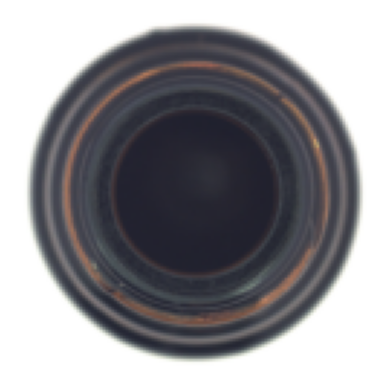

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

sample_path = "mvtec_rgb128/bottle/train/good/000.png"
img = Image.open(sample_path)

print("Size:", img.size)
print("Mode:", img.mode)

plt.imshow(img)
plt.axis("off")

In [10]:
import wandb
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("WANBD_API_KEY")

if api_key:
    os.environ["WANDB_API_KEY"] = api_key
    wandb.login(key=api_key)
else:
    print("WANDB_API_KEY no está")


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\mauri\_netrc
wandb: Currently logged in as: mauu (mauu-tec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [11]:
from src.data import MVTecDataset

train_ds = MVTecDataset("mvtec_rgb128", "train", "cable")
test_ds  = MVTecDataset("mvtec_rgb128", "test",  "cable")

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))

# Debe imprimir SOLO "good" en train
unique_train_defects = set([d for _,_,d in train_ds])
print("Train defect types:", unique_train_defects)

# Test debe mostrar varios tipos
unique_test_defects = set([d for _,_,d in test_ds])
print("Test defect types:", unique_test_defects)


Train samples: 224
Test samples: 150
Train defect types: {'good'}
Test defect types: {'cut_outer_insulation', 'poke_insulation', 'cut_inner_insulation', 'cable_swap', 'combined', 'good', 'missing_cable', 'missing_wire', 'bent_wire'}


In [12]:
import torch

# Configurar precisión para Tensor Cores (API nueva)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"TF32 para matmul: {torch.backends.cuda.matmul.allow_tf32}")
print(f"TF32 para cuDNN: {torch.backends.cudnn.allow_tf32}")

AssertionError: Torch not compiled with CUDA enabled

In [13]:
from src.data import MVTecDataset

train_ds = MVTecDataset("mvtec_rgb128", "train", "cable")
test_ds  = MVTecDataset("mvtec_rgb128", "test",  "cable")

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))

# Debe imprimir SOLO "good" en train
unique_train_defects = set([d for _,_,d in train_ds])
print("Train defect types:", unique_train_defects)

# Test debe mostrar varios tipos
unique_test_defects = set([d for _,_,d in test_ds])
print("Test defect types:", unique_test_defects)


Train samples: 224
Test samples: 150
Train defect types: {'good'}
Test defect types: {'cut_outer_insulation', 'poke_insulation', 'cut_inner_insulation', 'cable_swap', 'combined', 'good', 'missing_cable', 'missing_wire', 'bent_wire'}


In [3]:
import os

# Crear estructura de carpetas
os.makedirs("src/models", exist_ok=True)

data_py = """from torch.utils.data import Dataset
from PIL import Image
import os

class MVTecDataset(Dataset):
    def __init__(self, root_dir, split='train', class_name=['cable'], transform=None):
        self.paths = []
        self.labels = []
        self.defect_names = []
        
        # Compatibilidad: si viene un string, convertir a lista
        if isinstance(class_name, str):
            class_name = [class_name]
        
        # Iterar sobre todas las clases
        for cls in class_name:
            base = os.path.join(root_dir, cls, split)
            
            # --- ENTRENAMIENTO: solo good ---
            if split == "train":
                good_path = os.path.join(base, "good")
                for f in os.listdir(good_path):
                    if f.lower().endswith((".png", ".jpg", ".jpeg")):
                        self.paths.append(os.path.join(good_path, f))
                        self.labels.append(0)  # 0 = good
                        self.defect_names.append("good")
            
            # --- TEST/VALIDATION: good + TODOS los defectos ---
            else:
                for subclass in os.listdir(base):
                    sub_path = os.path.join(base, subclass)
                    if not os.path.isdir(sub_path):
                        continue

                    for f in os.listdir(sub_path):
                        if f.lower().endswith((".png", ".jpg", ".jpeg")):
                            self.paths.append(os.path.join(sub_path, f))
                            is_good = (subclass == "good")
                            self.labels.append(0 if is_good else 1)
                            self.defect_names.append(subclass)

        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]          # 0 = good, 1 = defect
        defect = self.defect_names[idx]   # p. ej. "good", "bent_wire", etc.

        return img, label, defect
"""

with open("src/data.py", "w") as f:
    f.write(data_py)


# MODELO A: CNN desde cero (Scratch)
# ResNet-18 parcial: conv1 + conv2_x + conv3_x
resnet_partial_py = '''import torch
import torch.nn as nn
import torch.nn.functional as F


class BasicBlock(nn.Module):
   
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity  # Conexión residual
        out = self.relu(out)

        return out


class ResNet18Partial(nn.Module):
    #MODELO A
    
    # conv1: 7x7, 64
    # conv2_x: 3x3, 64 canales
    # conv3_x: 3x3, 128 canales

    
    def __init__(self, num_classes=2, in_channels=3):
        super().__init__()
        
        self.in_planes = 64
        
        # CONV1: 7x7, 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, 
                               padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # CONV2_X: 2 bloques básicos, 64 canales
        self.layer1 = self._make_layer(64, 2, stride=1)
        
        # CONV3_X: 2 bloques básicos, 128 canales
        self.layer2 = self._make_layer(128, 2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        
        # Inicialización de pesos al azar
        self._initialize_weights()
    
    def _make_layer(self, out_channels, num_blocks, stride):
        #capa con varios bloques básicos
        downsample = None
        
        # si hay cambio de dimensiones -> necesitamos downsample
        if stride != 1 or self.in_planes != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_planes, out_channels, kernel_size=1, 
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        layers = []
        # Primer bloque (puede tener stride > 1)
        layers.append(BasicBlock(self.in_planes, out_channels, stride, downsample))
        self.in_planes = out_channels
        
        # Bloques restantes (stride = 1)
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(self.in_planes, out_channels))
        
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        # inicialización aleatoria de pesos 
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # conv2_x
        x = self.layer1(x)
        
        # conv3_x
        x = self.layer2(x)
        
        # Clasificador
        x = self.avgpool(x)
        features = torch.flatten(x, 1)  # Para t-SNE u otras visualizaciones
        logits = self.fc(features)
        
        return logits, features


#AQUÍ VA EL MODELO B !!!!!!!!!!!!!
'''

with open("src/models/resnet_partial.py", "w") as f:
    f.write(resnet_partial_py)


#Lightning Module para Clasificación (Modelo A)
lightning_module_py = '''import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import wandb


class LitClassifier(pl.LightningModule):
    #Entrenamiento desde cero con pesos aleatorios

    def __init__(self, model, lr=1e-3, num_classes=2):
        super().__init__()
        self.model = model
        self.lr = lr
        self.num_classes = num_classes
        
        self.save_hyperparameters(ignore=['model'])
        
        # Pérdida de clasificación
        self.criterion = nn.CrossEntropyLoss()
        
        # Para acumular datos durante validación
        self.validation_outputs = []

    def training_step(self, batch, batch_idx):
        x, labels, _ = batch
        logits, features = self.model(x)
        
        loss = self.criterion(logits, labels)
        
        # Accuracy
        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels).float().mean()
        
        self.log("train/loss", loss, prog_bar=True)
        self.log("train/acc", acc, prog_bar=True)
        
        return loss

    def validation_step(self, batch, batch_idx):
        x, labels, defects = batch
        logits, features = self.model(x)
        loss = self.criterion(logits, labels)
        
        # Probabilidades y predicciones
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels).float().mean()
        
        self.log("val/loss", loss, prog_bar=True)
        self.log("val/acc", acc, prog_bar=True)
        
        # Guardar para visualizaciones
        self.validation_outputs.append({
            'logits': logits.detach().cpu(),
            'probs': probs.detach().cpu(),
            'preds': preds.cpu(),
            'labels': labels.cpu(),
            'features': features.detach().cpu(),
            'defects': defects
        })
        
        return loss

    def on_validation_epoch_end(self):
        if len(self.validation_outputs) == 0:
            return
        
        # Concatenar todos los resultados
        all_preds = torch.cat([o['preds'] for o in self.validation_outputs])
        all_labels = torch.cat([o['labels'] for o in self.validation_outputs])
        all_probs = torch.cat([o['probs'] for o in self.validation_outputs])
        all_features = torch.cat([o['features'] for o in self.validation_outputs])
        all_defects = [d for o in self.validation_outputs for d in o['defects']]
        
        # Métricas globales
        acc = (all_preds == all_labels).float().mean()
        
        # AUC-ROC (para clasificación binaria)
        if self.num_classes == 2:
            try:
                auc = roc_auc_score(all_labels.numpy(), all_probs[:, 1].numpy())
                self.log("val/auc", auc)
            except:
                pass
        
        # En la última época, generar visualizaciones
        if self.current_epoch == self.trainer.max_epochs - 1:
            # Matriz de confusión
            fig_cm = self._plot_confusion_matrix(all_preds.numpy(), all_labels.numpy())
            if fig_cm:
                self.logger.experiment.log({"visualizations/confusion_matrix": wandb.Image(fig_cm)})
                plt.close(fig_cm)
            
            # t-SNE
            fig_tsne = self._plot_tsne(all_features.numpy(), all_labels.numpy(), all_defects)
            if fig_tsne:
                self.logger.experiment.log({"visualizations/tsne": wandb.Image(fig_tsne)})
                plt.close(fig_tsne)
            
            # Tabla de predicciones
            self._log_predictions_table(all_preds, all_labels, all_probs, all_defects)
        
        self.validation_outputs.clear()

    def _plot_confusion_matrix(self, preds, labels):
        #Genera matriz de confusión
        cm = confusion_matrix(labels, preds)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Good', 'Defect'],
                    yticklabels=['Good', 'Defect'])
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
        ax.set_title('Matriz de Confusión - Modelo A (Scratch)')
        plt.tight_layout()
        return fig

    def _plot_tsne(self, features, labels, defects):
        #Visualización t-SNE del espacio de features
        max_samples = min(1000, len(features))
        indices = np.random.choice(len(features), max_samples, replace=False)
        
        feat_subset = features[indices]
        labels_subset = labels[indices]
        defects_subset = [defects[i] for i in indices]
        
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        features_2d = tsne.fit_transform(feat_subset)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot por label binario
        ax1 = axes[0]
        colors = ['blue' if l == 0 else 'red' for l in labels_subset]
        ax1.scatter(features_2d[:, 0], features_2d[:, 1], c=colors, alpha=0.6, s=20)
        ax1.set_title('t-SNE Modelo A: Good (azul) vs Defect (rojo)')
        ax1.set_xlabel('Dim 1')
        ax1.set_ylabel('Dim 2')
        
        # Plot por tipo de defecto
        ax2 = axes[1]
        unique_defects = list(set(defects_subset))
        cmap = plt.cm.get_cmap('tab20', len(unique_defects))
        defect_to_idx = {d: i for i, d in enumerate(unique_defects)}
        colors2 = [cmap(defect_to_idx[d]) for d in defects_subset]
        scatter = ax2.scatter(features_2d[:, 0], features_2d[:, 1], c=colors2, alpha=0.6, s=20)
        ax2.set_title('t-SNE por tipo de defecto')
        ax2.set_xlabel('Dim 1')
        ax2.set_ylabel('Dim 2')
        
        # Leyenda
        handles = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=cmap(defect_to_idx[d]), markersize=8, label=d)
                   for d in unique_defects]
        ax2.legend(handles=handles, loc='upper right', fontsize=8)
        
        plt.tight_layout()
        return fig

    def _log_predictions_table(self, preds, labels, probs, defects):
        #Registra tabla de predicciones en WandB
        columns = ["idx", "true_label", "pred_label", "prob_good", "prob_defect", "correct", "defect_type"]
        data = []
        
        for idx in range(len(preds)):
            data.append([
                idx,
                "good" if labels[idx] == 0 else "defect",
                "good" if preds[idx] == 0 else "defect",
                f"{probs[idx, 0]:.4f}",
                f"{probs[idx, 1]:.4f}",
                "✓" if preds[idx] == labels[idx] else "✗",
                defects[idx]
            ])
        
        table = wandb.Table(data=data, columns=columns)
        self.logger.experiment.log({"predictions/all": table})

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.trainer.max_epochs)
        return [optimizer], [scheduler]
'''

with open("src/lightning_module.py", "w") as f:
    f.write(lightning_module_py)

# script de entrenamiento para Modelo A
train_py = '''import hydra
from omegaconf import DictConfig
from torchvision import transforms
from torch.utils.data import DataLoader
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

from data import MVTecDataset
from models.resnet_partial import ResNet18Partial
from lightning_module import LitClassifier


@hydra.main(config_path="../conf", config_name="config", version_base=None)
def main(cfg: DictConfig):

    wandb_logger = WandbLogger(
        project=cfg.logger.project,
        entity=cfg.logger.entity,
        log_model=cfg.logger.log_model
    )

    # Transformaciones (con augmentation para train)
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_ds = MVTecDataset(
        root_dir=cfg.dataset.root,
        split="train",
        class_name=cfg.dataset.class_name,
        transform=train_transform
    )

    val_ds = MVTecDataset(
        root_dir=cfg.dataset.root,
        split="test",
        class_name=cfg.dataset.class_name,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.dataset.batch_size,
        shuffle=True,
        num_workers=4
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.dataset.batch_size,
        shuffle=False,
        num_workers=4
    )

    # llamada al modelo
    num_classes = cfg.model.num_classes
    model = ResNet18Partial(num_classes=num_classes)
    
    print("=" * 60)
    print("MODELO A: CNN ResNet-18 Parcial (Scratch)")
    print("Pesos inicializados ALEATORIAMENTE")
    print("=" * 60)

    lit_model = LitClassifier(
        model=model,
        lr=cfg.train.lr,
        num_classes=num_classes
    )

    # Callbacks
    checkpoint_callback = ModelCheckpoint(
        monitor='val/acc',
        mode='max',
        save_top_k=1,
        filename='modelo_A-{epoch:02d}-{val_acc:.4f}'
    )
    
    early_stop_callback = EarlyStopping(
        monitor='val/loss',
        patience=5,
        mode='min'
    )

    trainer = Trainer(
        max_epochs=cfg.trainer.max_epochs,
        accelerator=cfg.trainer.accelerator,
        devices=cfg.trainer.devices,
        logger=wandb_logger,
        log_every_n_steps=cfg.trainer.log_every_n_steps,
        callbacks=[checkpoint_callback, early_stop_callback]
    )

    trainer.fit(lit_model, train_loader, val_loader)


if __name__ == "__main__":
    main()
'''

with open("src/train.py", "w") as f:
    f.write(train_py)

# Crear archivos __init__.py para que sean paquetes Python
with open("src/__init__.py", "w") as f:
    f.write("")

with open("src/models/__init__.py", "w") as f:
    f.write("")

print("MODELO A CREADO EXITOSAMENTE")
print("Arquitectura: ResNet-18 Parcial (conv1 + conv2_x + conv3_x)")

print("Archivos creados:")
print("  - src/data.py")
print("  - src/models/resnet_partial.py  (incluye placeholder para Modelo B)")
print("  - src/lightning_module.py")
print("  - src/train.py")

Estructura de carpeta src creada exitosamente!


In [15]:

!python src/train.py

c:\Users\mauri\miniconda3\envs\tarea05\lib\site-packages\hydra\_internal\defaults_list.py:251: UserWarning: In 'config': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
c:\Users\mauri\miniconda3\envs\tarea05\lib\site-packages\pytorch_lightning\utilities\parsing.py:210: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
Error executing job with overrides: []

Traceback (most recent call last):
  File "c:\Users\mauri\OneDrive\Documentos\tareasIA\Tareas-IA\src\train.py", line 70, in main
    trainer = Trainer(
  File "c:\Users\mauri\miniconda3\envs\tarea05\lib\site-packages\pytorch_lightning\utilities\argparse.py", line 70, in insert_env_defaults
    return fn(self, **kwargs)
  File "c:\Users\mauri\miniconda3\envs\tarea05\lib\site-packages\pytorch_l